<a href="https://colab.research.google.com/github/nitheensakthe/DataScience-Hackthon-Project-2/blob/main/41_OTT_%E2%80%94_WHY_DO_USERS_STOP_WATCHING_NITHEEN_SAKTHE_PE_24CS316.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/ott_user_behavior_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,User_ID,Viewing_History,Session_Duration,Content_Genre,Subscription_Plan,Inactivity_Period,Retention_Status
0,U01297,Comedy|Thriller|Documentary|Drama|Sci-Fi,74.6,Documentary,Premium,6.0,Retained
1,U00218,Thriller|Documentary|Sci-Fi|Romance,25.0,Thriller,Basic,4.0,At Risk
2,U00320,Documentary|Thriller|Sci-Fi|Romance,42.7,Thriller,Standard,6.1,Retained
3,U01383,Drama|Thriller|Comedy|Documentary|Sports,68.8,Drama,Standard,3.6,Retained
4,U01192,Sci-Fi,17.6,Sci-Fi,Premium,12.5,Retained


In [ ]:
# Display basic information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            10000 non-null  object 
 1   Viewing_History    10000 non-null  object 
 2   Session_Duration   10000 non-null  float64
 3   Content_Genre      10000 non-null  object 
 4   Subscription_Plan  10000 non-null  object 
 5   Inactivity_Period  10000 non-null  float64
 6   Retention_Status   10000 non-null  object 
dtypes: float64(2), object(5)
memory usage: 547.0+ KB


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Session_Duration,Inactivity_Period
count,10000.000000,10000.000000
mean,44.165620,8.187990
std,17.750107,4.537929
min,3.000000,0.000000
25%,31.700000,5.000000
50%,43.500000,7.300000
75%,56.200000,11.600000
max,106.400000,30.500000


In [ ]:
# Check for missing values in each column
display(df.isnull().sum())

,0
User_ID,0
Viewing_History,0
Session_Duration,0
Content_Genre,0
Subscription_Plan,0
Inactivity_Period,0
Retention_Status,0


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [ ]:
# Explore the distribution of 'Subscription_Plan'
print("\nDistribution of Subscription Plans:")
display(df['Subscription_Plan'].value_counts())


Distribution of Subscription Plans:


,count
Subscription_Plan,
Basic,4053
Standard,3777
Premium,2170


In [ ]:
# Explore the distribution of 'Content_Genre'
print("\nDistribution of Content Genres:")
display(df['Content_Genre'].value_counts())


Distribution of Content Genres:


,count
Content_Genre,
Drama,1307
Sports,1286
Documentary,1268
Romance,1254
Thriller,1231
Comedy,1224
Action,1222
Sci-Fi,1208


In [ ]:
# Explore the distribution of 'Retention_Status'
print("\nDistribution of Retention Status:")
display(df['Retention_Status'].value_counts())


Distribution of Retention Status:


,count
Retention_Status,
At Risk,5779
Retained,4221


In [ ]:
# Split 'Viewing_History' into individual genres and create a new column 'Individual_Genres'
df['Individual_Genres'] = df['Viewing_History'].apply(lambda x: x.split('|'))

# Display the first few rows with the new column
display(df[['User_ID', 'Viewing_History', 'Individual_Genres']].head())

,User_ID,Viewing_History,Individual_Genres
0,U01297,Comedy|Thriller|Documentary|Drama|Sci-Fi,"[Comedy, Thriller, Documentary, Drama, Sci-Fi]"
1,U00218,Thriller|Documentary|Sci-Fi|Romance,"[Thriller, Documentary, Sci-Fi, Romance]"
2,U00320,Documentary|Thriller|Sci-Fi|Romance,"[Documentary, Thriller, Sci-Fi, Romance]"
3,U01383,Drama|Thriller|Comedy|Documentary|Sports,"[Drama, Thriller, Comedy, Documentary, Sports]"
4,U01192,Sci-Fi,[Sci-Fi]


In [ ]:
# Flatten the list of lists to count individual genre occurrences
all_genres = [genre for genres_list in df['Individual_Genres'] for genre in genres_list]

# Count the occurrences of each genre
genre_counts = pd.Series(all_genres).value_counts()

print("\nTop 10 most viewed genres:")
display(genre_counts.head(10))


Top 10 most viewed genres:


,count
Drama,3918
Comedy,3902
Action,3869
Documentary,3854
Sports,3823
Thriller,3763
Romance,3755
Sci-Fi,3725


In [ ]:
# Calculate content diversity for each user (number of unique genres watched)
df['Content_Diversity'] = df['Individual_Genres'].apply(lambda x: len(set(x)))

print("\nContent Diversity for the first 5 users:")
display(df[['User_ID', 'Content_Diversity']].head())


Content Diversity for the first 5 users:


,User_ID,Content_Diversity
0,U01297,5
1,U00218,4
2,U00320,4
3,U01383,5
4,U01192,1


In [ ]:
# Calculate average session duration by Subscription Plan
print("\nAverage Session Duration by Subscription Plan:")
display(df.groupby('Subscription_Plan')['Session_Duration'].mean().sort_values(ascending=False))


Average Session Duration by Subscription Plan:


,Session_Duration
Subscription_Plan,
Premium,54.810876
Standard,46.282552
Basic,36.493314


In [ ]:
# Calculate average session duration by Retention Status
print("\nAverage Session Duration by Retention Status:")
display(df.groupby('Retention_Status')['Session_Duration'].mean().sort_values(ascending=False))


Average Session Duration by Retention Status:


,Session_Duration
Retention_Status,
Retained,54.728169
At Risk,36.450701


In [ ]:
# Calculate average session duration by Subscription Plan and Retention Status
print("\nAverage Session Duration by Subscription Plan and Retention Status:")
display(df.groupby(['Subscription_Plan', 'Retention_Status'])['Session_Duration'].mean().unstack())


Average Session Duration by Subscription Plan and Retention Status:


Retention_Status,At Risk,Retained
Subscription_Plan,,
Basic,30.804624,47.883333
Premium,46.859818,61.456937
Standard,38.834387,55.490231


In [ ]:
# Examine the relationship between Content Diversity and Session Duration (as a proxy for engagement)
print("\nCorrelation between Content Diversity and Session Duration:")
display(df[['Content_Diversity', 'Session_Duration']].corr())


Correlation between Content Diversity and Session Duration:


,Content_Diversity,Session_Duration
Content_Diversity,1.000000,0.553933
Session_Duration,0.553933,1.000000


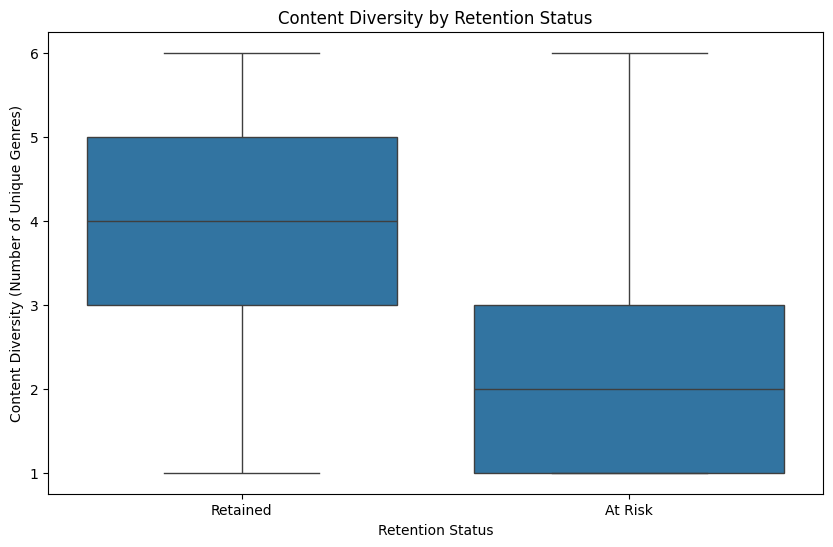

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Content Diversity by Retention Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Retention_Status', y='Content_Diversity', data=df)
plt.title('Content Diversity by Retention Status')
plt.xlabel('Retention Status')
plt.ylabel('Content Diversity (Number of Unique Genres)')
plt.show()

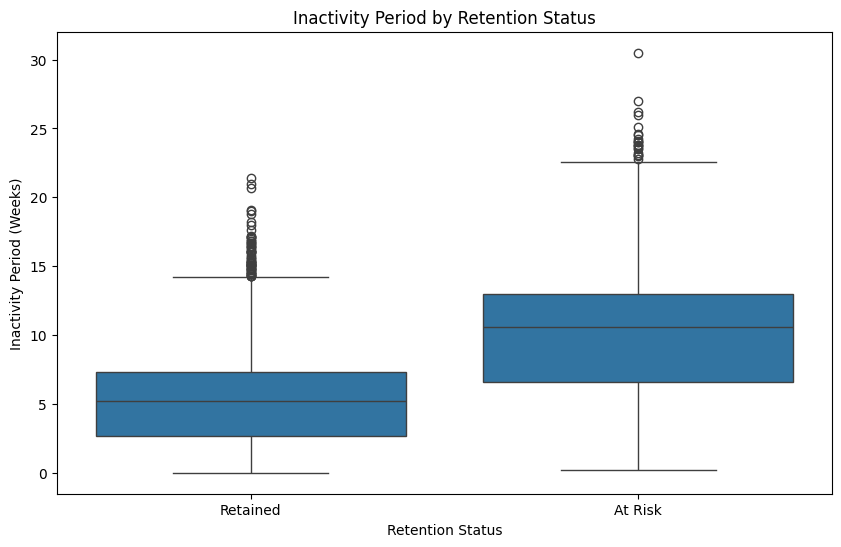

In [ ]:
# Visualize Inactivity Period by Retention Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Retention_Status', y='Inactivity_Period', data=df)
plt.title('Inactivity Period by Retention Status')
plt.xlabel('Retention Status')
plt.ylabel('Inactivity Period (Weeks)')
plt.show()

In [ ]:
# Calculate average Inactivity Period by Retention Status
print("\nAverage Inactivity Period by Retention Status:")
display(df.groupby('Retention_Status')['Inactivity_Period'].mean().sort_values(ascending=False))


Average Inactivity Period by Retention Status:


,Inactivity_Period
Retention_Status,
At Risk,10.202838
Retained,5.429448


In [ ]:
# Compare different subscription plans based on Retention Status distribution
print("\nRetention Status distribution by Subscription Plan:")
display(pd.crosstab(df['Subscription_Plan'], df['Retention_Status'], normalize='index') * 100)


Retention Status distribution by Subscription Plan:


Retention_Status,At Risk,Retained
Subscription_Plan,,
Basic,66.691340,33.308660
Premium,45.529954,54.470046
Standard,55.281970,44.718030


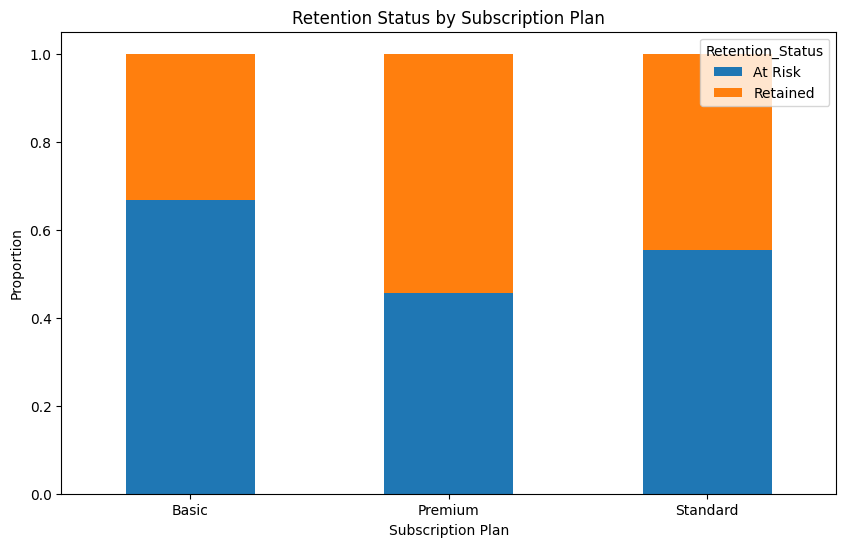

In [ ]:
import numpy as np

# Create a visualization for Retention Status distribution by Subscription Plan
retention_by_plan = pd.crosstab(df['Subscription_Plan'], df['Retention_Status'], normalize='index')
retention_by_plan.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Retention Status by Subscription Plan')
plt.xlabel('Subscription Plan')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

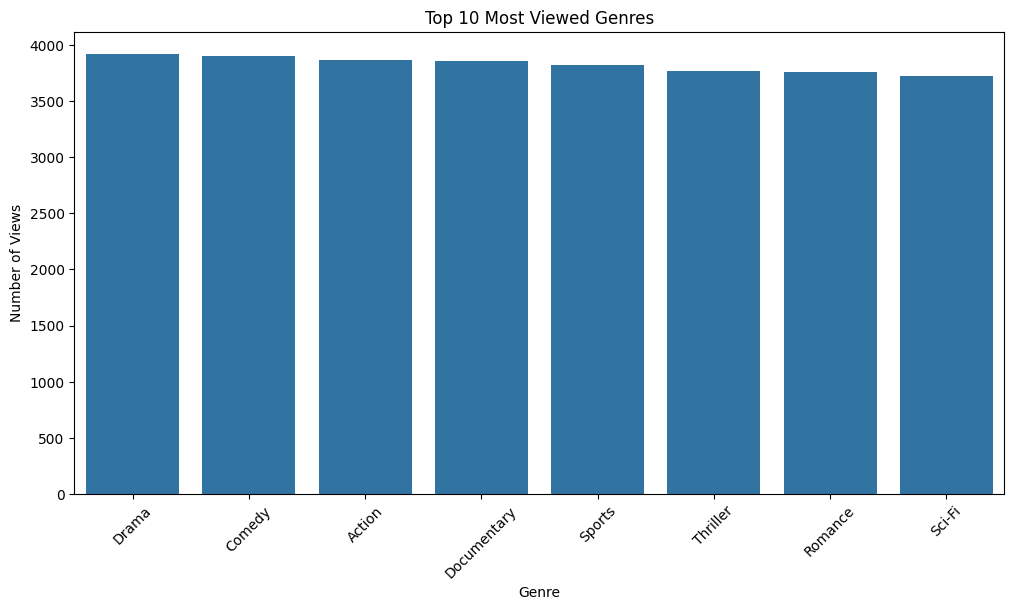

In [ ]:
# Create a visualization for Top 10 Most Viewed Genres
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values)
plt.title('Top 10 Most Viewed Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Views')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Prepare features (X) and target (y)
# Drop User_ID as it's an identifier and not a predictive feature
X = df.drop(['User_ID', 'Viewing_History', 'Individual_Genres', 'Retention_Status'], axis=1)
y = df['Retention_Status']

# Encode 'Subscription_Plan' using one-hot encoding
X = pd.get_dummies(X, columns=['Subscription_Plan'], drop_first=True)

# For 'Content_Genre', we have single genre in this column and multiple in 'Viewing_History' which is already processed to 'Individual_Genres'
# The original 'Content_Genre' column might not be as useful as 'Content_Diversity' which is derived from 'Viewing_History'
# Let's drop the original 'Content_Genre' column and use the 'Content_Diversity' as a feature.
X = X.drop('Content_Genre', axis=1)

# Encode the target variable 'Retention_Status'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) encoded head:")
display(pd.Series(y_encoded).head())

Features (X) head:


,Session_Duration,Inactivity_Period,Content_Diversity,Subscription_Plan_Premium,Subscription_Plan_Standard
0,74.6,6.0,5,True,False
1,25.0,4.0,4,False,False
2,42.7,6.1,4,False,True
3,68.8,3.6,5,False,True
4,17.6,12.5,1,True,False



Target (y) encoded head:


,0
0,1
1,0
2,1
3,1
4,1


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7000, 5)
X_test shape: (3000, 5)
y_train shape: (7000,)
y_test shape: (3000,)


In [ ]:
# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model Evaluation:
Accuracy: 0.7640

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.78      0.82      0.80      1710
    Retained       0.74      0.69      0.72      1290

    accuracy                           0.76      3000
   macro avg       0.76      0.75      0.76      3000
weighted avg       0.76      0.76      0.76      3000



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare features (X) and target (y)
# Drop User_ID as it's an identifier and not a predictive feature
X = df.drop(['User_ID', 'Viewing_History', 'Individual_Genres', 'Retention_Status'], axis=1)
y = df['Retention_Status']

# Encode 'Subscription_Plan' using one-hot encoding
X = pd.get_dummies(X, columns=['Subscription_Plan'], drop_first=True)

# For 'Content_Genre', we have single genre in this column and multiple in 'Viewing_History' which is already processed to 'Individual_Genres'
# The original 'Content_Genre' column might not be as useful as 'Content_Diversity' which is derived from 'Viewing_History'
# Let's drop the original 'Content_Genre' column and use the 'Content_Diversity' as a feature.
X = X.drop('Content_Genre', axis=1)

# Encode the target variable 'Retention_Status'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) encoded head:")
display(pd.Series(y_encoded).head())

Features (X) head:


,Session_Duration,Inactivity_Period,Content_Diversity,Subscription_Plan_Premium,Subscription_Plan_Standard
0,74.6,6.0,5,True,False
1,25.0,4.0,4,False,False
2,42.7,6.1,4,False,True
3,68.8,3.6,5,False,True
4,17.6,12.5,1,True,False



Target (y) encoded head:


,0
0,1
1,0
2,1
3,1
4,1


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7000, 5)
X_test shape: (3000, 5)
y_train shape: (7000,)
y_test shape: (3000,)


In [ ]:
# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model Evaluation:
Accuracy: 0.7640

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.78      0.82      0.80      1710
    Retained       0.74      0.69      0.72      1290

    accuracy                           0.76      3000
   macro avg       0.76      0.75      0.76      3000
weighted avg       0.76      0.76      0.76      3000

